# 影评分类：二分类问题示例

本实验使用 Keras 自带的 IMDB 数据集完成一个经典的二分类任务：

- 输入：一条电影评论（英文文本，已经被处理成数字序列）
- 输出：该评论是 **正面评价** 还是 **负面评价**
- 类别数：2 类

这是一个非常经典的自然语言处理入门案例，适合初学者理解：
1. 文本数据如何转换为神经网络能处理的数值形式
2. 二分类模型如何搭建
3. 训练集、验证集、测试集分别有什么作用
4. 如何观察过拟合现象
5. 如何用模型进行预测

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras import models
from tensorflow.keras import layers

## 1. IMDB 数据集说明

IMDB 数据集是电影评论数据集，常用于情感分析任务。

- 标签 0：负面评论
- 标签 1：正面评论

在 Keras 中，这个数据集已经被预处理过：
- 每条评论不再是原始英文句子
- 而是一个由整数构成的列表
- 每个整数表示一个单词在词表中的编号

为了简化实验，我们只保留训练集中最常出现的前 10000 个单词。

In [3]:
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

print("训练集样本数：", len(train_data))
print("测试集样本数：", len(test_data))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


E:\SDK-TOOL\versions\python_versions\python\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


训练集样本数： 25000
测试集样本数： 25000


In [4]:
print("第一条训练样本：")
print(train_data[0])

print("\n第一条训练样本对应的标签：")
print(train_labels[0])

第一条训练样本：
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]

第一条训练样本对应的标签：
1


## 2. 为什么这里的评论是一串数字？

因为神经网络不能直接处理字符串文本，所以需要先把文本变成数字。

在 IMDB 数据集中：
- 每条评论被编码成一个整数列表
- 每个整数代表一个单词
- 出现频率越高的单词，编号通常越靠前

我们可以尝试把这些数字解码回英文单词，帮助理解数据。

In [5]:
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

# Keras 编码时索引偏移了3，因为0,1,2是特殊符号
decoded_review = " ".join([reverse_word_index.get(i - 3, "?") for i in train_data[0]])
print(decoded_review)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should

## 3. 将整数序列转换为张量（向量化）

每条评论是长度不固定的整数列表，但神经网络要求输入具有固定形状。

这里使用 multi-hot 编码：
- 创建一个长度为 10000 的向量
    - 由于限定为前10 000个最常出现的单词，因此单词索引都不会超过10000。
- 如果某个单词在评论中出现过，就把对应位置设为 1
- 没出现过就设为 0

这样每条评论都能表示成固定的 10000 维向量。

In [6]:
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results

In [7]:
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

print("x_train 形状：", x_train.shape)
print("x_test 形状：", x_test.shape)

x_train 形状： (25000, 10000)
x_test 形状： (25000, 10000)


In [11]:
print("第一条评论向量化后：")
print(x_train[0])
print(x_train[0].shape)

第一条评论向量化后：
[0. 1. 1. ... 0. 0. 0.]
(10000,)


## 4. 构建神经网络

二分类问题的网络设计：
- 输出层只有 1 个神经元
- 激活函数使用 sigmoid（输出0~1之间的概率）

网络结构：
- 输入层：10000 维
- 隐藏层1：16 神经元，relu
- 隐藏层2：16 神经元，relu
- 输出层：1 神经元，sigmoid

损失函数用 binary_crossentropy（二元交叉熵），优化器用 rmsprop。

In [13]:
# 用Sequential顺序堆叠各层
model = models.Sequential()

# 输入层+第一隐藏层：输入10000维（如词袋/one-hot文本），16个神经元，ReLU激活
model.add(layers.Dense(16, activation="relu", input_shape=(10000,)))

# 第二隐藏层：16个神经元，ReLU激活
# 第二隐藏层没有显式指定输入维度，它的输入就是上一层的输出——即第一隐藏层的 16维。 这里也就是(16,16)
model.add(layers.Dense(16, activation="relu"))

# 输出层：1个神经元，Sigmoid输出0~1的概率（用于二分类，如情感正/负）
model.add(layers.Dense(1, activation="sigmoid"))

E:\SDK-TOOL\versions\python_versions\python\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## 5. 划分验证集

从训练集中拿出前 10000 条作为验证集，用于：
- 监控模型在未参与训练数据上的表现
- 判断是否过拟合

In [15]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

print("验证集形状：", x_val.shape)
print("剩余训练集形状：", partial_x_train.shape)

验证集形状： (10000, 10000)
剩余训练集形状： (15000, 10000)


In [16]:
history = model.fit(
    partial_x_train,   # 训练集特征
    partial_y_train,   # 训练集标签
    epochs=20,         # 训练20轮
    batch_size=512,    # 每批512个样本
    validation_data=(x_val, y_val)  # 每轮结束后在验证集上评估
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 204ms/step - accuracy: 0.7654 - loss: 0.5305 - val_accuracy: 0.8637 - val_loss: 0.4029
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8924 - loss: 0.3305 - val_accuracy: 0.8728 - val_loss: 0.3345
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9151 - loss: 0.2504 - val_accuracy: 0.8799 - val_loss: 0.3037
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9334 - loss: 0.2028 - val_accuracy: 0.8896 - val_loss: 0.2753
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9435 - loss: 0.1703 - val_accuracy: 0.8796 - val_loss: 0.2961
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9539 - loss: 0.1447 - val_accuracy: 0.8797 - val_loss: 0.3079
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9603 - loss: 0.1252 - val_accuracy: 0.8867 - val_loss: 0.2908
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9671 - loss: 0.1090 - val_accuracy: 0.8859 - va

## 6. 分析训练结果

history 对象保存了每轮训练的信息：
- loss：训练损失
- val_loss：验证损失
- accuracy：训练准确率
- val_accuracy：验证准确率

In [17]:
history_dict = history.history
print(history_dict.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


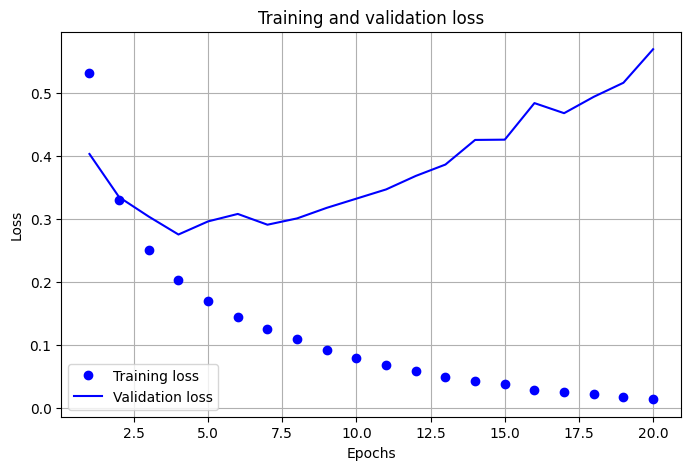

In [19]:
# 从历史记录中取出训练损失和验证损失
loss_values     = history_dict["loss"]
val_loss_values = history_dict["val_loss"]

# 生成轮次序列，从1开始
epochs = range(1, len(loss_values) + 1)

plt.figure(figsize=(8, 5))

# "bo"：蓝色圆点，画训练损失
plt.plot(epochs, loss_values,     "bo", label="Training loss")

# "b"：蓝色实线，画验证损失
plt.plot(epochs, val_loss_values, "b",  label="Validation loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(True)
plt.show()

### 损失曲线解读

- 训练损失持续下降：模型在训练集上越来越好
- 验证损失先降后升：出现 **过拟合**

大约在第4轮之后验证损失开始上升，说明训练轮数不宜过多。

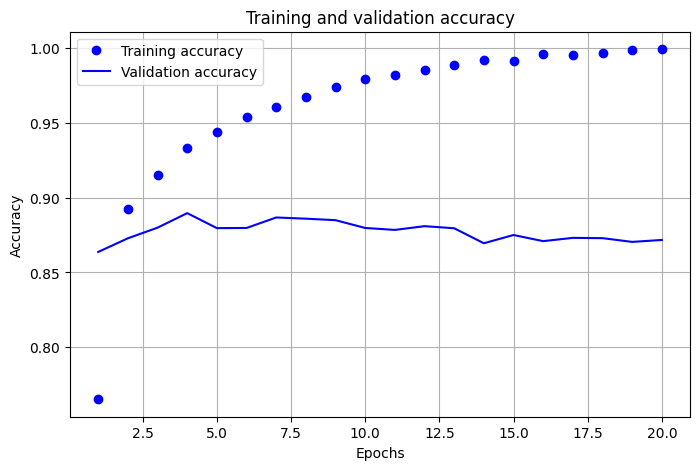

In [20]:
acc_values = history_dict["accuracy"]
val_acc_values = history_dict["val_accuracy"]

plt.figure(figsize=(8, 5))
plt.plot(epochs, acc_values, "bo", label="Training accuracy")
plt.plot(epochs, val_acc_values, "b", label="Validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 7. 重新训练合适的模型

观察到过拟合后，我们重新训练只训练4轮。

In [21]:
model = models.Sequential()
model.add(layers.Dense(16, activation="relu", input_shape=(10000,)))
model.add(layers.Dense(16, activation="relu"))
model.add(layers.Dense(1, activation="sigmoid"))

model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.fit(x_train, y_train, epochs=4, batch_size=512)

E:\SDK-TOOL\versions\python_versions\python\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8170 - loss: 0.4595
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9017 - loss: 0.2761
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9251 - loss: 0.2113
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9340 - loss: 0.1827


## 8. 测试集评估

测试集用于模拟未知新数据，检查模型泛化能力。
测试集不能参与训练过程。

In [22]:
results = model.evaluate(x_test, y_test)
print("测试损失：", results[0])
print("测试准确率：", results[1])

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 977us/step - accuracy: 0.8845 - loss: 0.2878
测试损失： 0.28781720995903015
测试准确率： 0.8844799995422363


## 9. 使用模型预测

sigmoid 输出的是概率值：
- 接近 1：正面评论
- 接近 0：负面评论

In [23]:
predictions = model.predict(x_test)
print("前10条预测概率：")
print(predictions[:10])

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 716us/step
前10条预测概率：
[[0.14609234]
 [0.9994236 ]
 [0.7556329 ]
 [0.83105314]
 [0.93158436]
 [0.7208915 ]
 [0.99926865]
 [0.0068895 ]
 [0.96038014]
 [0.9860634 ]]


In [24]:
# 概率转类别：>=0.5 为正面(1)，<0.5 为负面(0)
predicted_labels = (predictions >= 0.5).astype("int32")
print("前20条预测类别：")
print(predicted_labels[:20].flatten())

前20条预测类别：
[0 1 1 1 1 1 1 0 1 1 1 0 0 0 1 0 1 1 0 0]
